In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
FLOW_2DET = pd.read_csv("../Files/timing_results_Flow_2DET.csv")
ORIGINAL_2DET = pd.read_csv("../Files/timing_results_Original_2DET.csv")
FLOW_3DET = pd.read_csv("../Files/timing_results_Flow_3DET.csv")
ORIGINAL_3DET = pd.read_csv("../Files/timing_results_Original_3DET.csv")

In [3]:
fractions = FLOW_2DET["template_fraction"].drop_duplicates().to_numpy()
mean_Flow_2DET = []
mean_Original_2DET = []
std_Flow_2DET = []
std_Original_2DET = []
mean_Flow_3DET = []
mean_Original_3DET = []
std_Flow_3DET = []
std_Original_3DET = []

for frac in fractions:
    x = FLOW_2DET.loc[FLOW_2DET["template_fraction"] == frac, "runtime_seconds"].to_numpy()
    mean_Flow_2DET.append(np.mean(x))
    std_Flow_2DET.append(np.std(x))

for frac in fractions:
    x2 = ORIGINAL_2DET.loc[ORIGINAL_2DET["template_fraction"] == frac, "runtime_seconds"].to_numpy()
    mean_Original_2DET.append(np.mean(x2))
    std_Original_2DET.append(np.std(x2))

mean_Flow_2DET = np.array(mean_Flow_2DET)
std_Flow_2DET = np.array(std_Flow_2DET)
mean_Original_2DET = np.array(mean_Original_2DET)
std_Original_2DET = np.array(std_Original_2DET)

for frac in fractions:
    x = FLOW_3DET.loc[FLOW_3DET["template_fraction"] == frac, "runtime_seconds"].to_numpy()
    mean_Flow_3DET.append(np.mean(x))
    std_Flow_3DET.append(np.std(x))

for frac in fractions:
    x2 = ORIGINAL_3DET.loc[ORIGINAL_3DET["template_fraction"] == frac, "runtime_seconds"].to_numpy()
    mean_Original_3DET.append(np.mean(x2))
    std_Original_3DET.append(np.std(x2))

mean_Flow_3DET = np.array(mean_Flow_3DET)
std_Flow_3DET = np.array(std_Flow_3DET)
mean_Original_3DET = np.array(mean_Original_3DET)
std_Original_3DET = np.array(std_Original_3DET)


Templates = [11,23,69,139,231,347,695]

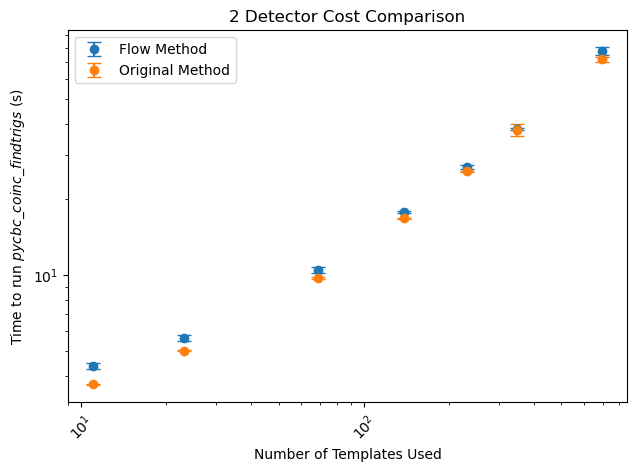

In [4]:

plt.errorbar(
    Templates,
    mean_Flow_2DET,
    yerr=std_Flow_2DET,
    fmt='o',
    capsize=5,
    label = "Flow Method"
)
plt.errorbar(
    Templates,
    mean_Original_2DET,
    yerr=std_Original_2DET,
    fmt='o',
    capsize=5,
    label = "Original Method"
)

plt.xticks(rotation=45)
plt.xlabel("Number of Templates Used")
plt.ylabel(r"Time to run $\it{pycbc\_coinc\_findtrigs}$ (s)")
plt.title("2 Detector Cost Comparison")
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.savefig("../Plots/Cost_2DET.png")
plt.show()

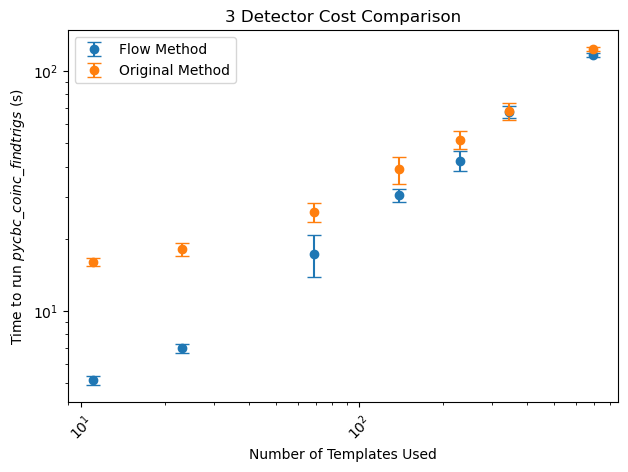

In [5]:
plt.errorbar(
    Templates,
    mean_Flow_3DET,
    yerr=std_Flow_3DET,
    fmt='o',
    capsize=5,
    label = "Flow Method"
)
plt.errorbar(
    Templates,
    mean_Original_3DET,
    yerr=std_Original_3DET,
    fmt='o',
    capsize=5,
    label = "Original Method"
)

plt.xticks(rotation=45)
plt.xlabel("Number of Templates Used")
plt.ylabel(r"Time to run $\it{pycbc\_coinc\_findtrigs}$ (s)")
plt.title("3 Detector Cost Comparison")
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.savefig("../Plots/Cost_3DET.png")
plt.show()

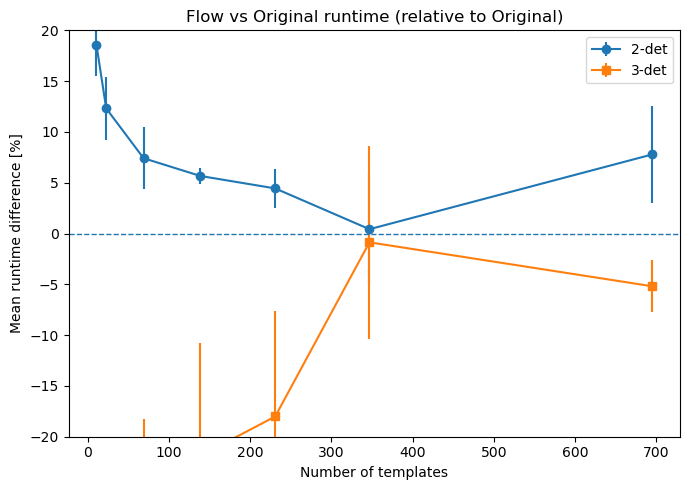

In [14]:
pct_diff_2DET = 100.0 * (mean_Flow_2DET - mean_Original_2DET) / mean_Original_2DET
pct_diff_3DET = 100.0 * (mean_Flow_3DET - mean_Original_3DET) / mean_Original_3DET


pct_err_2DET = 100.0 * np.sqrt(
    (std_Flow_2DET / mean_Original_2DET)**2 +
    ((mean_Flow_2DET * std_Original_2DET) / mean_Original_2DET**2)**2
)

pct_err_3DET = 100.0 * np.sqrt(
    (std_Flow_3DET / mean_Original_3DET)**2 +
    ((mean_Flow_3DET * std_Original_3DET) / mean_Original_3DET**2)**2
)

import matplotlib.pyplot as plt

Templates = np.array([11, 23, 69, 139, 231, 347, 695])

plt.figure(figsize=(7,5))

plt.errorbar(
    Templates, pct_diff_2DET, yerr=pct_err_2DET,
    marker='o', linestyle='-', label='2-det'
)

plt.errorbar(
    Templates, pct_diff_3DET, yerr=pct_err_3DET,
    marker='s', linestyle='-', label='3-det'
)

plt.axhline(0, linestyle='--', linewidth=1)

plt.xlabel("Number of templates")
plt.ylabel("Mean runtime difference [%]")
plt.title("Flow vs Original runtime (relative to Original)")
plt.legend()
plt.ylim(-20,20)
plt.tight_layout()
plt.show()
